# XGBoost — Practical Implementation on Real Projects

This notebook applies **XGBoost-style gradient boosting** to the **same two projects** used throughout
this series:
1. **Holiday Package Prediction** (classification)
2. **Car Price Prediction** (regression)





In [5]:
!pip install xgboost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, roc_curve)

np.random.seed(42)

---
# Part A — Holiday Package Prediction (Classification)


In [2]:
df = pd.read_csv("Travel.csv")
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried')
features_with_na = [f for f in df.columns if df[f].isnull().sum() >= 1]

# Impute (fill) missing values in each column
for f in features_with_na:
    if not pd.api.types.is_numeric_dtype(df[f]):
        df[f] = df[f].fillna(df[f].mode()[0])
    else:
        df[f] = df[f].fillna(df[f].median())
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [3]:
df.drop('CustomerID', axis=1, inplace=True)
df['TotalVisiting'] = (df['NumberOfPersonVisiting'] + df['NumberOfChildrenVisiting'])
df.drop(['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'],axis=1,inplace=True)
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [4]:
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_features = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
num_features = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]

preprocessor = ColumnTransformer(transformers=[
    ('OneHotEncoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ('StandardScaler', StandardScaler(), num_features)
])

X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("Train:", X_train_transformed.shape, " Test:", X_test_transformed.shape)

Train: (3910, 26)  Test: (978, 26)


## A.3 Train & Compare: Random Forest, AdaBoost, XGBoost-style (HistGB)

Same reusable loop pattern used throughout this whole series.

In [5]:
!pip install xgboost

In [6]:
from xgboost import XGBClassifier

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train_transformed, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    y_train_proba = model.predict_proba(X_train_transformed)[:, 1]
    y_test_proba = model.predict_proba(X_test_transformed)[:, 1]

    results.append({
        "Model": name,

        # Accuracy
        "Train Accuracy": round(accuracy_score(y_train, y_train_pred), 3),
        "Test Accuracy": round(accuracy_score(y_test, y_test_pred), 3),

        # Precision
        "Train Precision": round(precision_score(y_train, y_train_pred), 3),
        "Test Precision": round(precision_score(y_test, y_test_pred), 3),

        # Recall
        "Train Recall": round(recall_score(y_train, y_train_pred), 3),
        "Test Recall": round(recall_score(y_test, y_test_pred), 3),

        # F1
        "Train F1": round(f1_score(y_train, y_train_pred), 3),
        "Test F1": round(f1_score(y_test, y_test_pred), 3),

        # ROC-AUC
        "Train ROC-AUC": round(roc_auc_score(y_train, y_train_proba), 3),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_test_proba), 3),
    })


results_df = (
    pd.DataFrame(results)
    .sort_values("Test ROC-AUC", ascending=False)
)

results_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Random Forest,1.000,0.939,1.000,0.977,1.000,0.690,1.000,0.809,1.000,0.962
2,XGBoost,1.000,0.931,1.000,0.893,0.999,0.723,0.999,0.799,1.000,0.957
1,AdaBoost,0.849,0.837,0.779,0.727,0.273,0.217,0.404,0.335,0.835,0.772


## A.4 Hyperparameter Tuning — XGBoost

Tuning XGBoost's key hyperparameters:
- `n_estimators` ↔ controls the number of boosting rounds (trees)
- `learning_rate` ↔ shrinkage rate / `eta`
- `max_depth` ↔ controls tree depth (complexity)
- `reg_lambda` ↔ L2 regularization term on weights (the **λ** from the theory notes!)
- `gamma` ↔ minimum loss reduction required to make a further partition on a leaf node of the tree
- `subsample` ↔ subsample ratio of the training instance
- `colsample_bytree` ↔ subsample ratio of columns when constructing each tree

In [7]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

xgb_params = {
    "n_estimators": [100, 150, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "reg_lambda": [0, 0.5, 1, 2, 5],
    "gamma": [0, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_distributions=xgb_params,
    n_iter=20,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)
random_search_xgb.fit(X_train_transformed, y_train)
print("Best Parameters for XGBoost:", random_search_xgb.best_params_)

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.6, 0.8, 1.0]
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)
random_search_rf.fit(X_train_transformed, y_train)
print("Best Parameters for Random Forest:", random_search_rf.best_params_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:49:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'subsample': 1.0, 'reg_lambda': 0.5, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best Parameters for Random Forest: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.8, 'max_depth': None}


In [8]:
# Get the best tuned models
best_xgb = random_search_xgb.best_estimator_
best_rf = random_search_rf.best_estimator_

models = {
    "Tuned Random Forest": best_rf,
    "Tuned XGBoost": best_xgb
}

results = []

for name, model in models.items():

    # Train
    model.fit(X_train_transformed, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_transformed)
    y_test_pred = model.predict(X_test_transformed)

    # Probabilities for ROC-AUC
    y_train_proba = model.predict_proba(X_train_transformed)[:, 1]
    y_test_proba = model.predict_proba(X_test_transformed)[:, 1]

    results.append({
        "Model": name,

        # Accuracy
        "Train Accuracy": round(accuracy_score(y_train, y_train_pred), 3),
        "Test Accuracy": round(accuracy_score(y_test, y_test_pred), 3),

        # Precision
        "Train Precision": round(precision_score(y_train, y_train_pred), 3),
        "Test Precision": round(precision_score(y_test, y_test_pred), 3),

        # Recall
        "Train Recall": round(recall_score(y_train, y_train_pred), 3),
        "Test Recall": round(recall_score(y_test, y_test_pred), 3),

        # F1
        "Train F1": round(f1_score(y_train, y_train_pred), 3),
        "Test F1": round(f1_score(y_test, y_test_pred), 3),

        # ROC-AUC
        "Train ROC-AUC": round(roc_auc_score(y_train, y_train_proba), 3),
        "Test ROC-AUC": round(roc_auc_score(y_test, y_test_proba), 3),
    })


results_df_tuned = (
    pd.DataFrame(results)
    .sort_values("Test ROC-AUC", ascending=False)
)

results_df_tuned

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:51:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Tuned Random Forest,1.000,0.946,1.0,0.946,1.000,0.755,1.000,0.840,1.0,0.961
1,Tuned XGBoost,0.999,0.939,1.0,0.925,0.993,0.734,0.997,0.818,1.0,0.959


## A.5 Final Comparison — ROC Curve (All 3 Models)

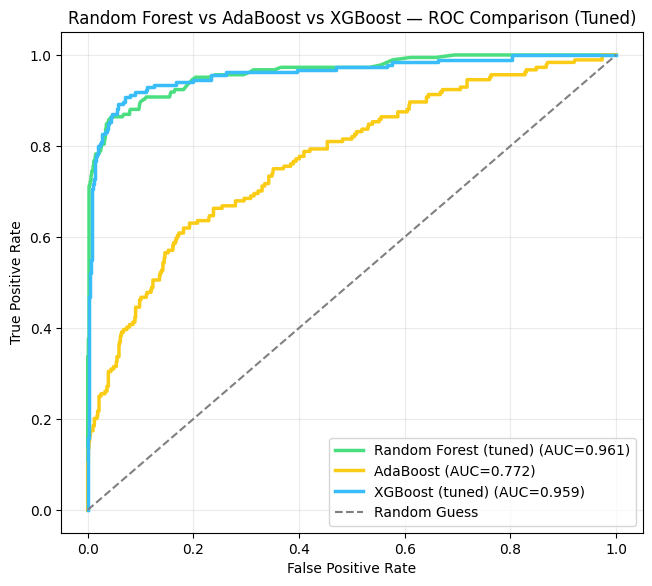

In [9]:
# Get the best tuned models (assuming they are already available from cell 9CpHIZnSyjjy)
best_xgb_tuned = best_xgb
best_rf_tuned = best_rf

ada = AdaBoostClassifier(random_state=42) # Keep original AdaBoost for comparison
ada.fit(X_train_transformed, y_train) # Fit AdaBoost here

plt.figure(figsize=(7.5, 6.5))
for name, model, color in [
    ("Random Forest (tuned)", best_rf_tuned, "#4ade80"),
    ("AdaBoost", ada, "#facc15"),
    ("XGBoost (tuned)", best_xgb_tuned, "#38bdf8"),
]:
    prob = model.predict_proba(X_test_transformed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2.5)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest vs AdaBoost vs XGBoost — ROC Comparison (Tuned)")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## A.6 Feature Importance (via Permutation Importance)

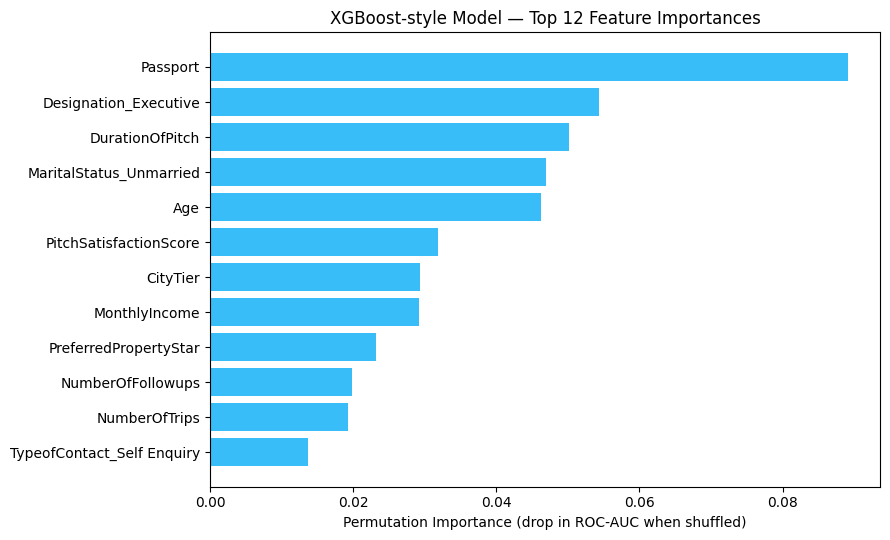

In [10]:
from sklearn.inspection import permutation_importance

result = permutation_importance(best_xgb, X_test_transformed, y_test,
                                  n_repeats=10, random_state=42, n_jobs=-1)

# Recover readable feature names from the ColumnTransformer
ohe_names = preprocessor.named_transformers_['OneHotEncoder'].get_feature_names_out(cat_features)
all_feature_names = list(ohe_names) + num_features

order = np.argsort(result.importances_mean)[::-1][:12]

plt.figure(figsize=(9, 5.5))
plt.barh([all_feature_names[i] for i in order][::-1], result.importances_mean[order][::-1], color="#38bdf8")
plt.xlabel("Permutation Importance (drop in ROC-AUC when shuffled)")
plt.title("XGBoost-style Model — Top 12 Feature Importances")
plt.tight_layout()
plt.show()

---
# Part B — Car Price Prediction (Regression)


## B.1 Recreate the Synthetic Car Price Dataset (same as Notebooks 04 & 06)

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(7)


df2 = pd.read_csv(r"cardekho_imputated.csv", index_col=[0])
df2.drop(['car_name', 'brand'], axis=1, inplace=True)
df2.head()

X2 = df2.drop('selling_price', axis=1)
y2 = df2['selling_price']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

label_encoder = LabelEncoder()
label_encoder.fit(X2_train['model'])
known_models = set(label_encoder.classes_)

X2_train = X2_train.copy()
X2_test = X2_test.copy()
X2_train['model'] = label_encoder.transform(X2_train['model'])
X2_test['model'] = X2_test['model'].apply(lambda v: v if v in known_models else label_encoder.classes_[0])
X2_test['model'] = label_encoder.transform(X2_test['model'])

onehot_columns = ['seller_type', 'fuel_type', 'transmission_type']
numeric_columns = [c for c in X2.columns if pd.api.types.is_numeric_dtype(X2[c]) and c != 'model']

preprocessor2 = ColumnTransformer(transformers=[
    ('OneHotEncoder', OneHotEncoder(drop='first', handle_unknown='ignore'), onehot_columns),
    ('StandardScaler', StandardScaler(), numeric_columns)
], remainder='passthrough')

X2_train_t = preprocessor2.fit_transform(X2_train)
X2_test_t = preprocessor2.transform(X2_test)

print("Train:", X2_train_t.shape, " Test:", X2_test_t.shape)


Train: (12328, 14)  Test: (3083, 14)


## B.3 Train & Compare: Random Forest, AdaBoost, XGBoost-style (HistGB)

In [12]:
from xgboost import XGBRegressor

reg_models = {
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42), # Using XGBoost directly
}

reg_results = []
for name, model in reg_models.items():
    model.fit(X2_train_t, y2_train)
    train_r2 = r2_score(y2_train, model.predict(X2_train_t))
    test_r2 = r2_score(y2_test, model.predict(X2_test_t))
    test_mae = mean_absolute_error(y2_test, model.predict(X2_test_t))
    reg_results.append({"Model": name, "Train R2": round(train_r2, 3), "Test R2": round(test_r2, 3),
                          "Test MAE": round(test_mae, 0)})

pd.DataFrame(reg_results).sort_values("Test R2", ascending=False)

,Model,Train R2,Test R2,Test MAE
0,Random Forest,0.973,0.935,100801.0
2,XGBoost,0.991,0.753,102835.0
1,AdaBoost,0.770,0.721,340496.0


## B.4 Hyperparameter Tuning — XGBoost-style Regressor

In [13]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

xgb_reg_params = {
    "n_estimators": [100, 150, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "reg_lambda": [0, 0.5, 1, 2, 5],
    "gamma": [0, 0.1, 0.2, 0.3],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
}

random_search_xgb_reg = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_reg_params,
    n_iter=20,
    cv=3,
    verbose=0, # Changed verbose to 0 for cleaner output
    random_state=42,
    n_jobs=-1
)
random_search_xgb_reg.fit(X2_train_t, y2_train)
print("Best Parameters for XGBoost Regressor:", random_search_xgb_reg.best_params_)

best_xgb_reg = random_search_xgb_reg.best_estimator_
print(f"\nTuned Test R2 (XGBoost): {r2_score(y2_test, best_xgb_reg.predict(X2_test_t)):.3f}")

# Hyperparameter tuning for Random Forest Regressor
rf_reg_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 0.6, 0.8, 1.0]
}

random_search_rf_reg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_reg_params,
    n_iter=20,
    cv=3,
    verbose=0,
    random_state=42,
    n_jobs=-1
)
random_search_rf_reg.fit(X2_train_t, y2_train)
print("\nBest Parameters for Random Forest Regressor:", random_search_rf_reg.best_params_)

best_rf_reg = random_search_rf_reg.best_estimator_
print(f"Tuned Test R2 (Random Forest): {r2_score(y2_test, best_rf_reg.predict(X2_test_t)):.3f}")

Best Parameters for XGBoost Regressor: {'subsample': 1.0, 'reg_lambda': 0.5, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}

Tuned Test R2 (XGBoost): 0.781

Best Parameters for Random Forest Regressor: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.6, 'max_depth': None}
Tuned Test R2 (Random Forest): 0.940


## B.5 Actual vs Predicted — Visual Check

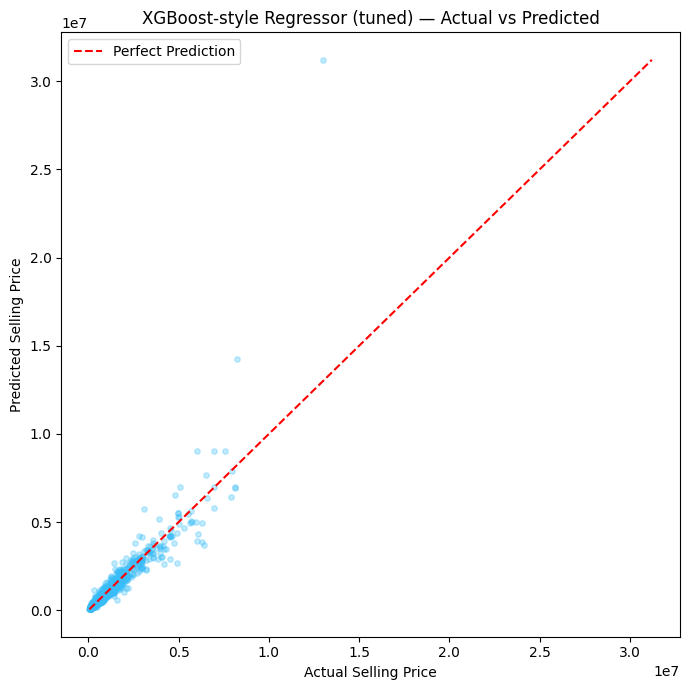

In [14]:
y2_pred = best_xgb_reg.predict(X2_test_t)

plt.figure(figsize=(7, 7))
plt.scatter(y2_test, y2_pred, alpha=0.3, color="#38bdf8", s=15)
lims = [min(y2_test.min(), y2_pred.min()), max(y2_test.max(), y2_pred.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("XGBoost-style Regressor (tuned) — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


---
# Part C — What Real `xgboost` Adds Beyond This Notebook's Stand-in


In [ ]:
# NOTE: requires the real `xgboost` package (pip install xgboost) -- not installed in this sandbox.

'''
from xgboost import XGBClassifier, XGBRegressor

# --- Classification: drop-in replacement for HistGradientBoostingClassifier above ---
xgb_clf = XGBClassifier(
    n_estimators=200,       # <-> max_iter
    learning_rate=0.1,
    max_depth=6,            # XGBoost splits by depth, not max_leaf_nodes
    reg_lambda=1,           # <-> l2_regularization
    gamma=0,                # minimum Gain required to split further (no HistGB equivalent)
    subsample=0.8,          # row sampling per tree
    colsample_bytree=0.8,   # feature sampling per tree
    random_state=42,
    eval_metric='auc'
)
xgb_clf.fit(X_train_transformed, y_train)
y_proba = xgb_clf.predict_proba(X_test_transformed)[:, 1]

# --- Regression: drop-in replacement for HistGradientBoostingRegressor above ---
xgb_reg = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    reg_lambda=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_reg.fit(X2_train_t, y2_train)
predictions = xgb_reg.predict(X2_test_t)

# Real XGBoost also gives you this directly (no permutation_importance workaround needed):
xgb_clf.feature_importances_
'''

print("Swap HistGradientBoosting*(...) for XGBClassifier/XGBRegressor(...) above -- same fit/predict API.")
